## Linear Regression using Gradient Descent
The model uses the linear equation:

$$
\hat{y} = wx + b
$$

where:

- $w$ is the **weight/slope**
- $b$ is the **bias/intercept**
- $\hat{y}$ is the predicted value

To optimize the parameters, we use **Gradient Descent** with **Mean Squared Error (MSE)** as the loss function:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i-y_i)^2
$$

Before training, the input feature is standardized using:

$$
X_{scaled} = \frac{X-\mu}{\sigma}
$$

This feature normalization helps gradient descent converge more reliably.

During every epoch, the algorithm:

1. Calculates predictions using the current values of $w$ and $b$.
2. Calculates the prediction error.
3. Computes the Mean Squared Error loss.
4. Calculates the gradients for the weight and bias.
5. Updates the parameters using the learning rate.
6. Stores the loss in `history` so that the training process can be visualized later.

The `predict()` method applies the same feature normalization used during training and returns predictions for new input data.


In [17]:
import numpy as np

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=1500):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = 0.0  #slope/weight
        self.b = 0.0  #intercept/bias
        self.history = []

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)
        n = len(X)

        #Feature normalization prevents vanishing/exploding gradients
        self.x_mean = np.mean(X)
        self.x_std = np.std(X)
        X_scaled = (X - self.x_mean) / self.x_std

        for epoch in range(1, self.epochs + 1):
            y_pred = (self.w * X_scaled) + self.b
            error = y_pred - y
            loss = np.mean(error**2) #MSE
            self.history.append(loss)

            dw = (2 / n) * np.dot(X_scaled, error) #weight gradient
            db = (2 / n) * np.sum(error) #bias gradient

            #Parameter updates
            self.w -= self.lr * dw
            self.b -= self.lr * db

            if epoch % 50 == 0 or epoch == 1: #logging
                print(f"[Epoch {epoch:03d}] Loss: {loss:.4f}")

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        X_scaled = (X - self.x_mean) / self.x_std
        return (self.w * X_scaled) + self.b

## Training the Linear Regression Model on California Housing Data

Using the **California Housing dataset** from Scikit-learn to train our custom Linear Regression model.

### Dataset

The California Housing dataset contains information about different districts in California. We select a random sample of **200 observations** for this demonstration.

The two variables used are:

- **`MedInc`** — Median income of households in the district. This is our **independent variable ($X$)**.
- **`MedHouseVal`** — Median house value in the district. This is our **dependent variable ($y$)**.

We want to learn the relationship:

$$
\text{MedHouseVal} = wX + b
$$

### Model Training

Our custom `LinearRegression` class is trained using:

- **Learning rate:** `0.05`
- **Epochs:** `300`

The model internally standardizes `MedInc` before training. Therefore, the learned weight `model.w` corresponds to the **scaled feature**, rather than the original `MedInc` values.

### Converting Parameters Back to the Original Scale

To make the final regression equation easier to interpret, we convert the learned weight and bias back to the original feature scale.

The original-scale slope is calculated as:

$$
slope = \frac{w}{\sigma_X}
$$

and the original-scale intercept is:

$$
intercept = b - \frac{w\mu_X}{\sigma_X}
$$

where:

- $w$ = learned weight on the standardized feature
- $b$ = learned bias
- $\mu_X$ = mean of `MedInc`
- $\sigma_X$ = standard deviation of `MedInc`

Finally, we obtain a regression equation in the form:

$$
\text{MedHouseVal} = slope \times \text{MedInc} + intercept
$$

The resulting equation describes the estimated relationship between **median household income** and **median house value** in the sampled data.


In [18]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame.sample(n=200, random_state=42)

X = df["MedInc"]       #independent variable
y = df["MedHouseVal"]  #dependent variable

model = LinearRegression(learning_rate=0.05, epochs=300)
model.fit(X, y)

# Unscaled slope and intercept (y = slope * X + intercept)
slope = model.w / model.x_std
intercept = model.b - (model.w * model.x_mean / model.x_std)
print(f"\nFitted Line: House Value ($100k) = {slope:.2f} * MedInc + {intercept:.2f}")

[Epoch 001] Loss: 5.3904
[Epoch 050] Loss: 0.7014
[Epoch 100] Loss: 0.7012
[Epoch 150] Loss: 0.7012
[Epoch 200] Loss: 0.7012
[Epoch 250] Loss: 0.7012
[Epoch 300] Loss: 0.7012

Fitted Line: House Value ($100k) = 0.38 * MedInc + 0.61


## Visualizing Model Training and Regression Results

1. **MSE Loss Convergence**
2. **Fitted Regression Line vs Observed Data**

### 1. MSE Loss Convergence

The first plot shows how the **Mean Squared Error (MSE)** changes during training.

The x-axis represents the number of **epochs**, while the y-axis represents the MSE loss.

As Gradient Descent updates the model parameters, the loss should generally decrease and eventually stabilize. This indicates that the model is converging toward parameters that minimize the prediction error.

A successful convergence pattern typically shows:

- High loss during the initial epochs.
- A rapid decrease in loss during early training.
- Gradual stabilization as the model approaches the minimum.
- Little improvement after the model has converged.

### 2. Fitted Regression Line vs Observed Data

The second plot shows the relationship between **Median Income (`MedInc`)** and **Median House Value (`MedHouseVal`)**.

- **Blue points** represent the observed data from the California Housing dataset.
- The **black line** represents the regression line learned by our model.
- The x-axis represents median income in units of **$10,000**.
- The y-axis represents median house value in units of **$100,000**.

The regression line is calculated using the fitted slope and intercept:

$$
\hat{y} = slope \times x + intercept
$$

The scatter plot allows us to visually assess how well the linear model captures the relationship between the independent and dependent variables.

The distance between an observed point and the regression line represents the **residual (prediction error)** for that observation.

Together, these plots help us understand both **how the model learned** and **how well the final linear relationship represents the observed data**.


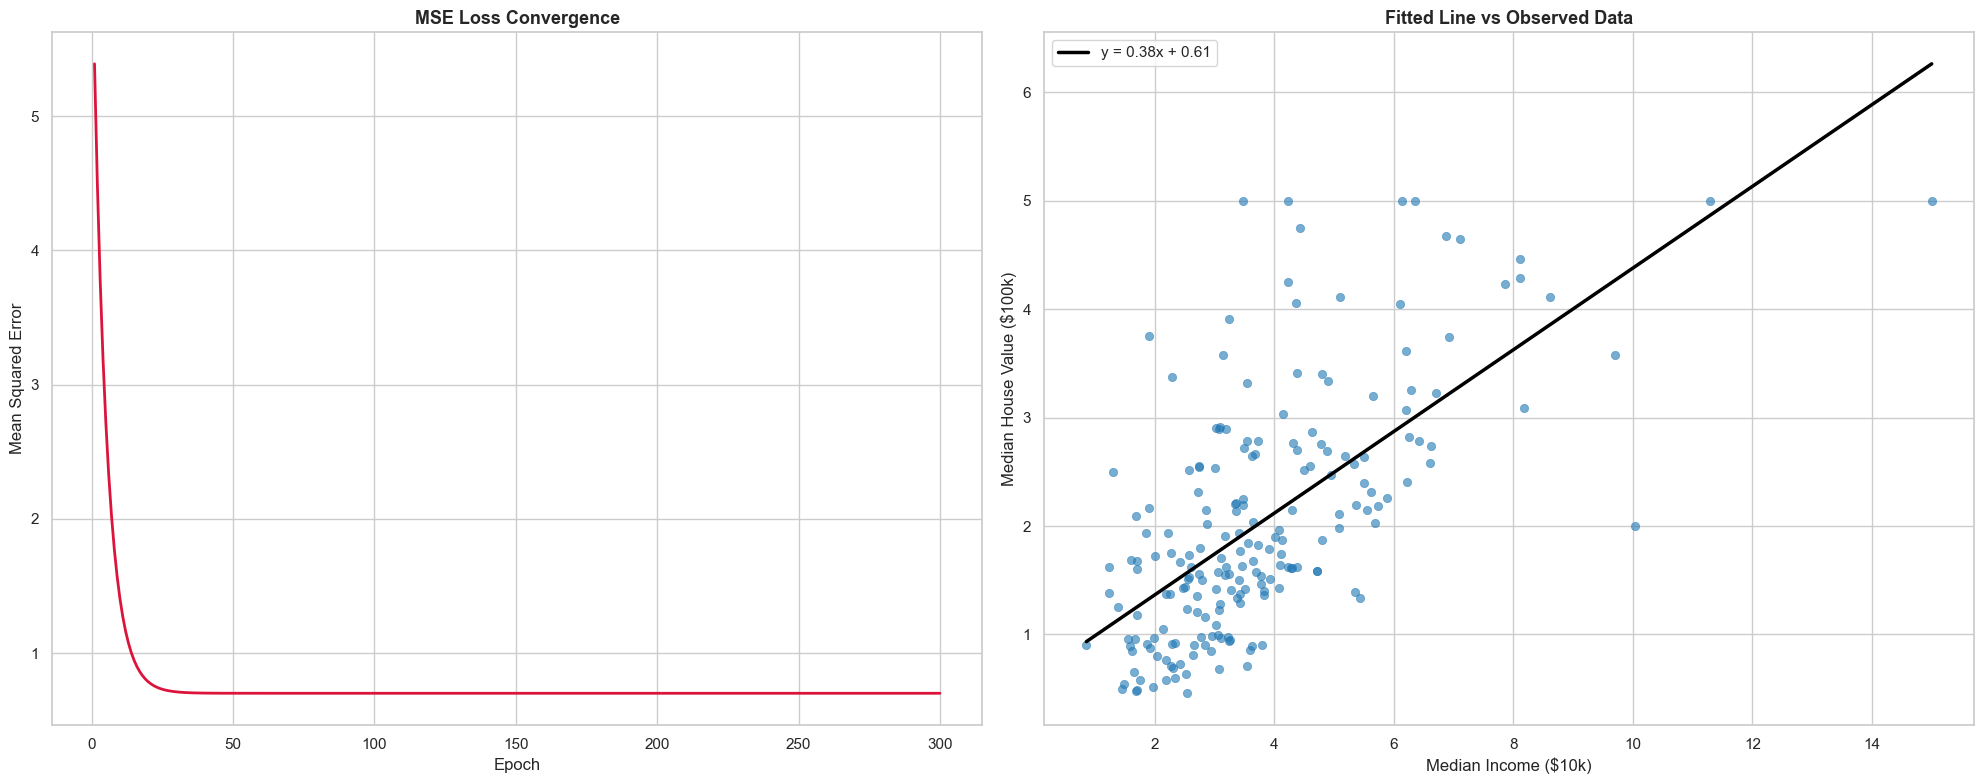

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

#loss convergence plot
axes[0].plot(range(1, len(model.history) + 1), model.history, color="crimson", linewidth=2)
axes[0].set_title("MSE Loss Convergence", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Squared Error")

#scatter plot for data
sns.scatterplot(
    data=df, 
    x="MedInc", 
    y="MedHouseVal", 
    ax=axes[1], 
    alpha=0.6, 
    color="#1f77b4",
    edgecolor=None
)

#line plot for regression line
x_vals = np.linspace(df["MedInc"].min(), df["MedInc"].max(), 100)
y_vals = slope * x_vals + intercept
axes[1].plot(x_vals, y_vals, color="black", linewidth=2.5, label=f"y = {slope:.2f}x + {intercept:.2f}")

axes[1].set_title("Fitted Line vs Observed Data", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Median Income ($10k)")
axes[1].set_ylabel("Median House Value ($100k)")
axes[1].legend()

plt.tight_layout()
plt.show()